<a href="https://colab.research.google.com/github/VeronicaMijares/Notebooks/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [ ]:
plans.head(5) # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
users.head(5)# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
usage.head(5) # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:

# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)


plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
print("Información de plans:")
plans.info() # inspección de plans con .info()

Información de plans:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
print("Información de users:")
users.info() # inspección de users con .info()

Información de users:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
print("Información de usage:")
usage.info() # inspección de usage con .info()

Información de usage:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:

# cantidad de nulos para users

print(users.isna().sum())

# Proporción de valores nulos
print(users.isna().mean())


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())

# Proporción de valores nulos
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.
Diagnóstico:
Se encontraron valores faltantes únicamente en city (11.725%) y churn_date (88.350%). Para city, se recomienda investigar la causa de los faltantes y evaluar una imputación, ya que representa una proporción moderada. En churn_date, se recomienda conservar los valores nulos, ya que la proporción es muy alta y, en este contexto, los valores nulos probablemente indican que el usuario continúa activo y no tiene una fecha de cancelación.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- Las columnas city en un 11.72% y churn_date en un 88.35%
- Indica qué harías: ¿imputar, eliminar, ignorar?
- Para la columna city lo recomendable es investigar e imputar conviene investigar la causa y evaluar imputación adecuada  y para la columna churn_date lo recomendable es ignorar ya que al superar el 80% al imputar podría introducir información incorrecta

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
print("USERS")
print(users.describe())

USERS
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` a simple vista no aparenta tener valores incorrectos... Haz doble clic en este bloque y escribe qué ves.
- La columna `age` en cambio para esta columna hay valores que no tienen sentido y son inválidos como -999 probablemente debe ser un valor faltante

In [ ]:
# explorar columnas numéricas de usage
print("USAGE")
print(usage.describe())

USAGE
                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- La columna id contiene identificadores consecutivos del 1 al 40,000, sin valores  inválidos y la columna user_id contiene valores entre 10,000 y 13,999, consistentes con los identificadores de usuarios de la tabla users.
- La columna duration presenta valores entre 0 y 120, el valor 0 y el máximo de 120 deben revisarse para determinar si representan valores válidos o posibles sentinels

In [ ]:


# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for columna in columnas_user:
    print(f"\nValores únicos de {columna}:")
    print(users[columna].unique())


Valores únicos de city:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Valores únicos de plan:
['Basico' 'Premium']


- La columna `city` debe ser revisada y corregida ya que contiene valores incorrectos ...
- La columna `plan` a simple vista se puede apreciar que no existen valores nulos ...

In [ ]:
# explorar columna categórica de usage
usage['type'] # completa el código
for columna in usage:
    print(f"\nValores únicos de {columna}:")
    print(usage[columna].unique())


Valores únicos de id:
[    1     2     3 ... 39998 39999 40000]

Valores únicos de user_id:
[10332 11458 11777 ... 10278 12723 13883]

Valores únicos de type:
['call' 'text']

Valores únicos de date:
['2024-01-01 00:00:00.000000000' '2024-01-01 00:06:30.969774244'
 '2024-01-01 00:13:01.939548488' ... '2024-06-29 23:46:58.060451510'
 '2024-06-29 23:53:29.030225754' '2024-06-30 00:00:00.000000000']

Valores únicos de duration:
[ 0.09   nan  1.53 ... 22.88 31.29 21.12]

Valores únicos de length:
[     nan 3.90e+01 3.60e+01 4.40e+01 7.00e+01 3.10e+01 8.50e+01 4.80e+01
 2.80e+01 5.90e+01 5.00e+01 5.20e+01 6.50e+01 4.70e+01 7.20e+01 3.70e+01
 6.60e+01 5.30e+01 2.40e+01 6.40e+01 5.40e+01 1.04e+02 4.20e+01 4.90e+01
 4.50e+01 2.60e+01 4.30e+01 2.10e+01 7.40e+01 5.80e+01 8.60e+01 2.90e+01
 7.30e+01 7.80e+01 3.50e+01 4.00e+01 5.60e+01 6.70e+01 9.40e+01 4.10e+01
 3.20e+01 5.70e+01 7.00e+00 7.60e+01 5.50e+01 2.70e+01 3.40e+01 3.30e+01
 5.10e+01 6.20e+01 6.00e+01 7.10e+01 9.10e+01 1.40e+01 3.80e+01

- La columna `type` ...
La columna  type contiene únicamente dos valores: call y text, que representan llamadas y mensajes de texto, respectivamente. No se identificaron categorías inesperadas o valores aparentemente inválidos, por lo que la información de esta columna es consistente con el propósito del dataset

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  en las columnas duration y length
- ¿Qué acción tomarías?  En este caso, no deberíamos eliminar ni modificar datos automáticamente, porque primero debemos distinguir entre valores inválidos/sentinels y valores faltantes


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.


In [ ]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:

# Revisar los años presentes en `reg_date` de users


print(users['reg_date'].dt.year.value_counts().sort_index())


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.
Debe de existir cierto error porque según el proyecto la información esta actualizada hasta el año 2024 y aquí muestra información hasta el año 2026

In [ ]:
# Revisar los años presentes en `date` de usage
print(users['reg_date'].dt.year.value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:
Se observan 40registros con el año 2026 y de acuerdo al proyecto indica que la información está actualizada hasta el año 2024. Por lo tanto, estos registros están fuera del rango temporal esperado y podrían corresponder a un error en la captura, carga o actualización de los datos.
**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos) En sí el año 2026 no es un año imposible pero cambia la métrica porque ya estaríamos hablando de otros rangos
- ¿Qué harías con ellas?
- Como recomendación sería validar los 40 registros para verificar el origen y confirmar si son datos incorrectos, corregirlos o excluirlos para que no afecte el análisis

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
users['age'] = pd.to_numeric(users['age'], errors='coerce')
print(users['age'].describe())

count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
print(users['age'].describe())

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


In [ ]:

# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print("Valores nulos en city:", users['city'].isna().sum())

Valores nulos en city: 565


In [ ]:


# Convertir reg_date a formato fecha
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# Marcar fechas fuera de rango como nulas
users['reg_date'] = users['reg_date'].mask(users['reg_date'] > '2024-12-31')

# Verificar cambios
print("Valores nulos en reg_date:", users['reg_date'].isna().sum())

Valores nulos en reg_date: 40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:

# Verificación MAR en usage (Missing At Random) para duration
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().mean()))


type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
print(usage.groupby('type')['length'].apply(lambda x: x.isna().mean()))

type
call    0.99933
text    0.00000
Name: length, dtype: float64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Para duration pueden interpretarse como valores no aplicables (N/A) más que como datos realmente faltantes y no sería adecuado imputar estos valores de duration con la media o mediana. Para los registros text, los valores nulos deben mantenerse como NaN/nulos porque la duración no aplica a ese tipo de actividad.
para length os valores nulos de length están claramente relacionados con la variable type: el 99.93% de los registros de llamadas presentan length nulo, mientras que en los mensajes de texto no existen valores nulos. Esto indica que los valores faltantes no son aleatorios y corresponden a una variable que no aplica para las llamadas. Por lo tanto, se conservarán como valores nulos y no se realizará imputación.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas



# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# Observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:


# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# Observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(
    usage_agg,
    on="user_id",
    how="left"
)

# Observar resultado
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:

# Resumen estadístico de las columnas numéricas
columnas_numericas = [
    "age",
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamada"
]

user_profile[columnas_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

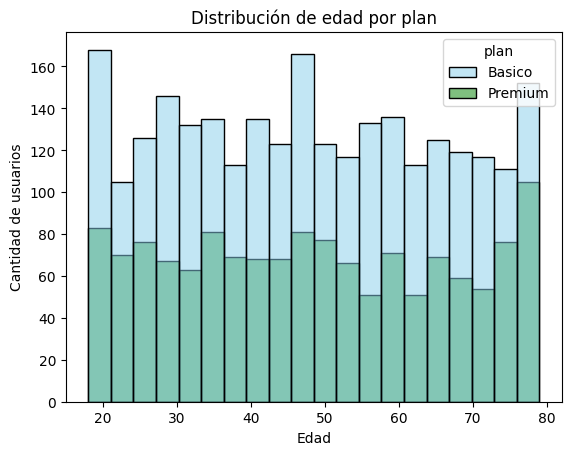

In [ ]:


# Histograma para visualizar la edad
sns.histplot(
    data=user_profile,
    x="age",
    hue="plan",
    palette=["skyblue", "green"],
    bins=20
)

plt.title("Distribución de edad por plan")
plt.xlabel("Edad")
plt.ylabel("Cantidad de usuarios")
plt.show()


💡Insights:
La distribución de edad se concentra principalmente alrededor de entre los 20s, 40s y 50s. Al comparar los planes, se observa que la gran mayoría de los usuarios cuentan con un plan básico.

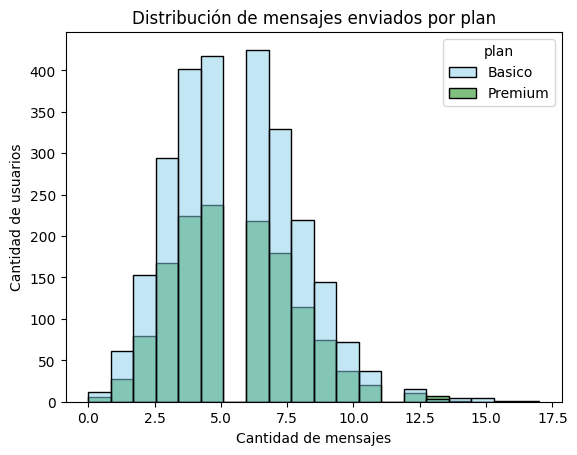

In [ ]:
# Histograma para visualizar la cantidad de mensajes
sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    palette=["skyblue", "green"],
    bins=20
)

plt.title("Distribución de mensajes enviados por plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights:
- La cantidad de mensajes presenta una distribución escalonada, con la mayor concentración de usuarios entre 5 y 7.5 mensajes. El plan premium muestra una mayor concentración de usuarios con un número elevado de mensajes.

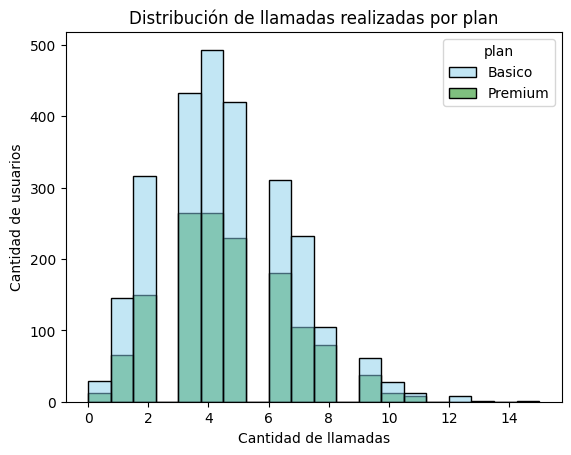

In [ ]:
# Histograma para visualizar la cantidad de llamadas
sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    palette=["skyblue", "green"],
    bins=20
)

plt.title("Distribución de llamadas realizadas por plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights:
La cantidad de llamadas presenta una distribución menor a comparación de mensajes, concentrándose principalmente entre 4 y 5 llamadas. En comparación con el envío de  mensajes. No se observa un patrón claro entre los planes.

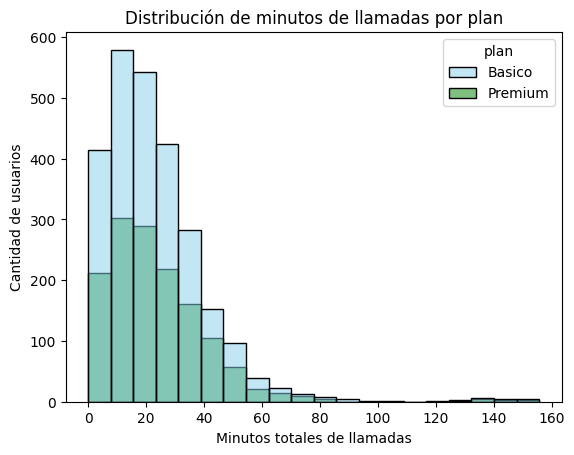

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
# Histograma para visualizar los minutos de llamadas
sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    palette=["skyblue", "green"],
    bins=20
)

plt.title("Distribución de minutos de llamadas por plan")
plt.xlabel("Minutos totales de llamadas")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights:
La distribución de los minutos de llamadas presenta mayoría en el plan básico, con la mayor concentración de usuarios en una media de 20-30 minutos. Los usuarios del plan básico presentan una mayor concentración en niveles altos de consumo.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

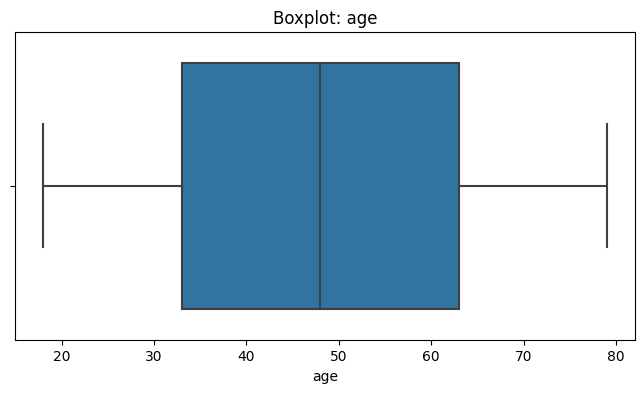

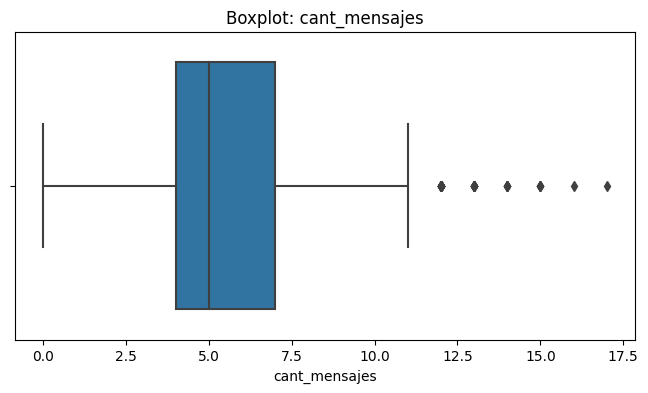

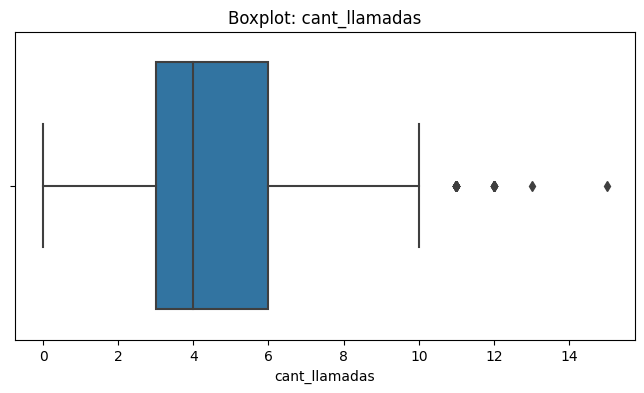

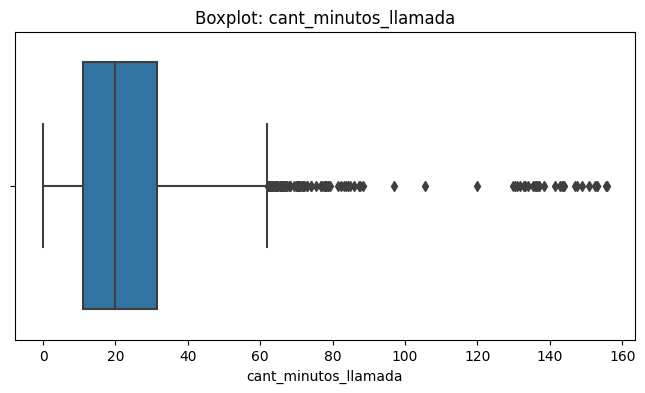

In [ ]:
# Visualizando usando BoxPlot

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights:
- Age: ...(presenta o no outliers)sin outliers.
- cant_mensajes: presenta múltiples outliers altos.
- cant_llamadas: presenta algunos outliers altos.
- cant_minutos_llamada: presenta múltiples outliers altos y valores extremos.

In [ ]:

# Calcular límites con el método IQR
columnas_limites = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    print(f"\n{col}")
    print(f"Límite inferior: {limite_inferior:.2f}")
    print(f"Límite superior: {limite_superior:.2f}")





age
Límite inferior: -12.00
Límite superior: 108.00

cant_mensajes
Límite inferior: -0.50
Límite superior: 11.50

cant_llamadas
Límite inferior: -1.50
Límite superior: 10.50

cant_minutos_llamada
Límite inferior: -19.32
Límite superior: 61.86


In [ ]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué? Mantener outliers ya que representan usuarios con un mayor nivel de actividad.
- cant_llamadas: mantener o no outliers, porqué? Mantener outliers. ya que pueden representar usuarios que realizan más llamadas de lo habitual.
- cant_minutos_llamada: mantener o no outliers, porqué? mantenerlos ya que reflejan usuarios con llamadas de mayor duración.

En conclusión mi recomendación es mantenerlos debido a que pueden representar comportamientos reales de los usuarios y no errores en los datos.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:

# Crear columna grupo_uso
import numpy as np

condiciones = [
    (user_profile['cant_llamadas'] < 5) &
    (user_profile['cant_mensajes'] < 5),

    (user_profile['cant_llamadas'] < 10) &
    (user_profile['cant_mensajes'] < 10)
]

valores = [
    'Bajo uso',
    'Uso medio'
]

user_profile['grupo_uso'] = np.select(
    condiciones,
    valores,
    default='Alto uso'
)

In [ ]:

# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:

# Crear columna grupo_edad

condiciones = [
    user_profile['age'] < 30,
    user_profile['age'] < 60
]

valores = [
    'Joven',
    'Adulto'
]

user_profile['grupo_edad'] = np.select(
    condiciones,
    valores,
    default='Adulto Mayor'
)

In [ ]:

# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

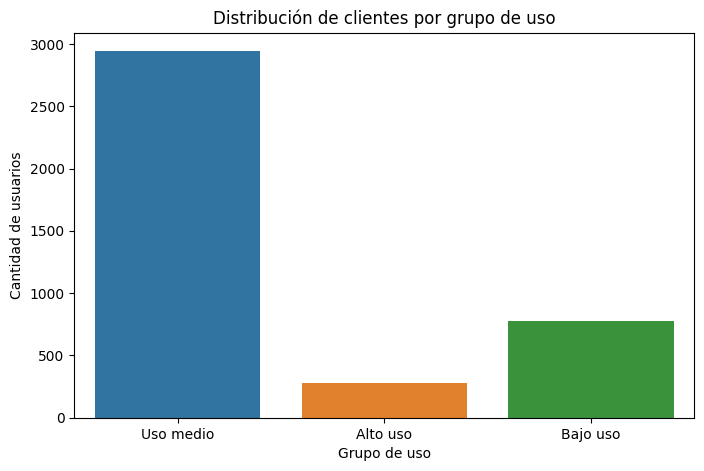

In [ ]:

# Visualización de los segmentos por uso

plt.figure(figsize=(8, 5))

sns.countplot(
    data=user_profile,
    x='grupo_uso'
)

plt.title('Distribución de clientes por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()


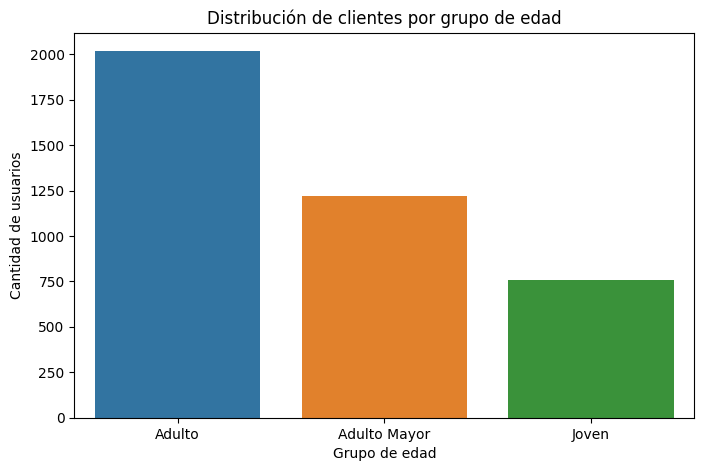

In [ ]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 5))

sns.countplot(
    data=user_profile,
    x='grupo_edad'
)

plt.title('Distribución de clientes por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
Durante la etapa de limpieza y exploración se identificaron varios problemas de calidad en los datos.

En la tabla users, la columna city presentaba valores faltantes en aproximadamente 11.73% de los registros, mientras que churn_date tenía aproximadamente 88.35% de valores nulos. En el caso de churn_date, estos valores pueden ser coherentes con usuarios que continúan activos, por lo que no necesariamente representan un error de captura.

También se identificaron valores utilizados como sentinels, particularmente el valor -999 en la columna age, que no representa una edad válida. Este valor fue tratado como dato faltante y posteriormente sustituido utilizando la mediana de edad.

En city se identificó el carácter ? como valor inválido, por lo que fue convertido a valor nulo. Asimismo, se revisaron las columnas de fechas para detectar valores imposibles o años fuera de rango y convertir los registros inválidos en valores nulos.

En la tabla usage, los valores faltantes de duration y length mostraron un patrón directamente relacionado con type. El 99.93% de los registros de tipo text no tiene duration, mientras que las llamadas no presentan valores faltantes en esta columna. De manera inversa, aproximadamente 99.93% de los registros de tipo call no tiene length, mientras que los mensajes no presentan valores faltantes en esta columna. Esto indica que estos valores no necesariamente son errores: corresponden principalmente a variables que no aplican según el tipo de actividad.

Por lo tanto, una de las principales conclusiones de la limpieza es que no todos los valores nulos deben imputarse. Algunos representan información no aplicable y conservarlos como nulos evita introducir información artificial en el análisis.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

- Por nivel de uso, los clientes fueron clasificados en:

Bajo uso: menos de 5 llamadas y menos de 5 mensajes.
Uso medio: menos de 10 llamadas y menos de 10 mensajes.
Alto uso: usuarios que no cumplen las condiciones anteriores.

Por edad, los clientes fueron clasificados en:

Joven: menores de 30 años.
Adulto: de 30 a 59 años.
Adulto Mayor: 60 años o más.

Esta segmentación permite analizar el comportamiento de los clientes desde dos dimensiones diferentes: sus características demográficas y su nivel de utilización de los servicios.


- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
  Para establecer qué segmento genera mayor valor para ConnectaTel sería necesario relacionar posteriormente estas métricas con variables como el plan contratado, ingresos generados y permanencia.

Por ello, la segmentación desarrollada debe utilizarse principalmente como una herramienta para identificar diferentes necesidades de los clientes y diseñar ofertas más ajustadas a sus patrones de consumo.

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
Se identificaron outliers en las tres variables de uso:

Mensajes: máximo de 17, frente a una mediana de 5.

Llamadas: máximo de 15, frente a una mediana de 4.

Minutos de llamada: máximo de 155.69 minutos, frente a una mediana de 19.78 minutos.

Estos valores representan clientes con un uso considerablemente superior al comportamiento típico.

Los outliers se mantienen porque pueden representar clientes reales con necesidades de consumo diferentes, por lo que también pueden ser una oportunidad para diseñar ofertas específicas.



- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
-
A partir de la segmentación y de los patrones de uso identificados, ConnectaTel podría considerar una estrategia de planes más orientada al comportamiento real de sus clientes.

1. Mantener una oferta diferenciada por nivel de consumo.
Los usuarios de bajo, medio y alto uso presentan necesidades diferentes. La empresa podría analizar si los límites actuales de los planes corresponden realmente a estos patrones de consumo.

2. Evaluar un plan para usuarios de alto consumo.
Los usuarios clasificados como Alto uso, especialmente aquellos con cantidades elevadas de llamadas, mensajes o minutos, podrían constituir un segmento para una oferta con mayores límites o beneficios adicionales.

3. Diseñar ofertas específicas para usuarios de consumo medio.
Este grupo podría representar una oportunidad para ofrecer paquetes intermedios que cubran mejor sus necesidades sin obligarlos a contratar una capacidad significativamente superior a la que utilizan.

4. Utilizar la edad como variable complementaria, no como único criterio comercial, ya que  permiten identificar diferencias demográficas, pero deberían combinarse con el comportamiento real de uso antes de diseñar ofertas específicas.

✍️ **Escribe aquí tu análisis ejecutivo:**

La limpieza de datos permitió transformar información con valores inválidos, sentinels y valores faltantes en una base más consistente para el análisis. Un hallazgo importante fue que varios valores nulos de usage no representan errores, sino variables que no aplican según el tipo de actividad.

La segmentación por edad y nivel de uso permite a ConnectaTel pasar de una visión general de sus clientes a una visión diferenciada de sus necesidades. Los usuarios de alto consumo pueden representar una oportunidad para desarrollar ofertas con mayor capacidad, mientras que los usuarios de bajo y medio consumo pueden beneficiarse de alternativas más ajustadas a su utilización real.

En conjunto, estos hallazgos sugieren que una estrategia basada en segmentación de clientes y comportamiento de uso puede ayudar a ConnectaTel a evaluar la estructura actual de sus planes y detectar oportunidades para ajustar su oferta, siempre complementando el análisis con variables comerciales como ingresos, permanencia y churn.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificaron valores inválidos o sentinels, como -999 en age y ? en city, además de fechas fuera de rango que requirieron limpieza.
  
- Los valores nulos en duration y length estuvieron relacionados con el tipo de actividad: duration no aplica prácticamente a los mensajes y length no aplica prácticamente a las llamadas. Por ello, estos valores se conservaron como nulos en lugar de imputarlos.
  
- La columna city presentó aproximadamente 11.73% de valores nulos, mientras que churn_date presentó aproximadamente 88.35%. En este último caso, los nulos pueden corresponder a usuarios que permanecen activos.
-Se encontraron 1 dato faltante en cant_mensajes, cant_llamadas y cant_minutos_llamada, equivalente al 0.025% de las 4,000 filas por variable.

-Se identificaron outliers en las variables de uso, principalmente en cant_mensajes, cant_llamadas y cant_minutos_llamada.

-Los outliers se mantienen, ya que pueden representar clientes con un uso real más alto y no necesariamente errores en los datos.
🔍 **Segmentos por Edad**
- La edad de los clientes va de 18 a 79 años, con una edad promedio de 48 años.

- La distribución muestra clientes de diferentes rangos de edad, por lo que ConnectaTel atiende a un público diverso.

- La edad por sí sola no permite explicar completamente el nivel de consumo; es importante combinarla con las variables de uso.


📊 **Segmentos por Nivel de Uso**
- Se observan clientes de bajo, medio y alto nivel de uso.

- El consumo típico se encuentra alrededor de 5 mensajes, 4 llamadas y 19.78 minutos de llamada.

- Existe un grupo de usuarios con un consumo significativamente mayor, especialmente en minutos de llamada, donde el máximo alcanza 155.69 minutos.


➡️ Esto sugiere que  ConnectaTel tiene perfiles de clientes con necesidades de consumo diferentes, por lo que una oferta diferenciada puede ser más adecuada que un único plan para todos, con esto daría un valor agregado y diferenciador del resto de su competencia.

💡 **Recomendaciones**
-Crear planes diferenciados por nivel de consumo: básico, medio y alto.

- Ofrecer planes con más minutos de llamada para los usuarios de alto consumo.

- Diseñar promociones para clientes de consumo medio que incentiven un mayor uso de los servicios.

- Mantener identificados a los usuarios de consumo extremo para ofrecerles planes personalizados.

- Utilizar edad + nivel de uso para mejorar la segmentación y personalizar las ofertas comerciales.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`